In [1]:
# 正则化表达

In [2]:
from transformers.models.xlstm.modeling_xlstm import xLSTMMultiHeadLayerNorm
%matplotlib inline

In [3]:
import torch
from torch import nn
from d2l import torch as d2l

In [4]:
n_train, n_test, num_input, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_input, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)  # 人工生成线性回归数据
train_iter = d2l.load_array(train_data, batch_size)  #  已有数据封装成iter迭代器
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size)

In [5]:
torch.ones((num_input, 1))

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
      

In [6]:
def init_params():
    w = torch.normal(0,1,size=(num_input, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return w, b  # 初始化参数

In [7]:
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2  #施加L2惩罚  pow幂运算

In [12]:
def train(lambd):
    w, b = init_params()
    net,loss = lambda X:d2l.linreg(X,w,b), d2l.squared_loss  # 匿名函数传递
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',xlim=[5,num_epochs],legend=['train','test'])
    for epoch in range(num_epochs):
        for X, Y in train_iter:
            l = loss(net(X), Y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w,b],lr,batch_size)
        if (epoch +1) %5 == 0:
            animator.add(epoch+1, (d2l.evaluate_loss(net,train_iter,loss),d2l.evaluate_loss(net,test_iter,loss)))
    print('w的L2范数为：', torch.norm(w).item())  # 先求范数 然后变成数值

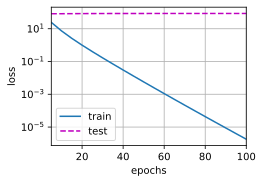

In [13]:
train(0)

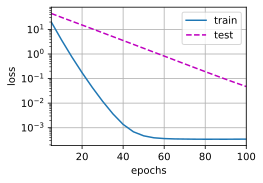

In [10]:
train(3)

In [16]:
def train_concise(wb):
    net = nn.Sequential(nn.Linear(num_input, 1))
    for param in net.parameters():
        param.data.normal_()  # 正态分布随机重新赋值
    loss = nn.MSELoss()
    num_epochs, lr = 100, 0.003
    trainer = torch.optim.SGD([{'params':net[0].weight,'weight_decay':wb},{'params':net[0].bias}], lr=lr)  # 只对w做权重衰减正则化
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',xlim=[5,num_epochs],legend=['train','test'])
    for epoch in range(num_epochs):
        for X, Y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), Y)
            l.mean().backward()
            trainer.step()
        if (epoch +1) %5 == 0:
            animator.add(epoch+1, (d2l.evaluate_loss(net,train_iter,loss),d2l.evaluate_loss(net,test_iter,loss)))
    print('w的L2范数为：', torch.norm(wb).item())

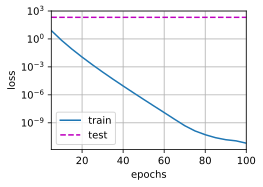

In [17]:
train_concise(0)

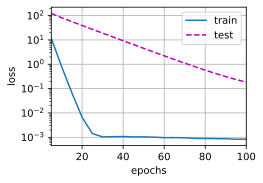

In [18]:
train_concise(3)